Baseline Best Epoch: 19, F1: 0.4645


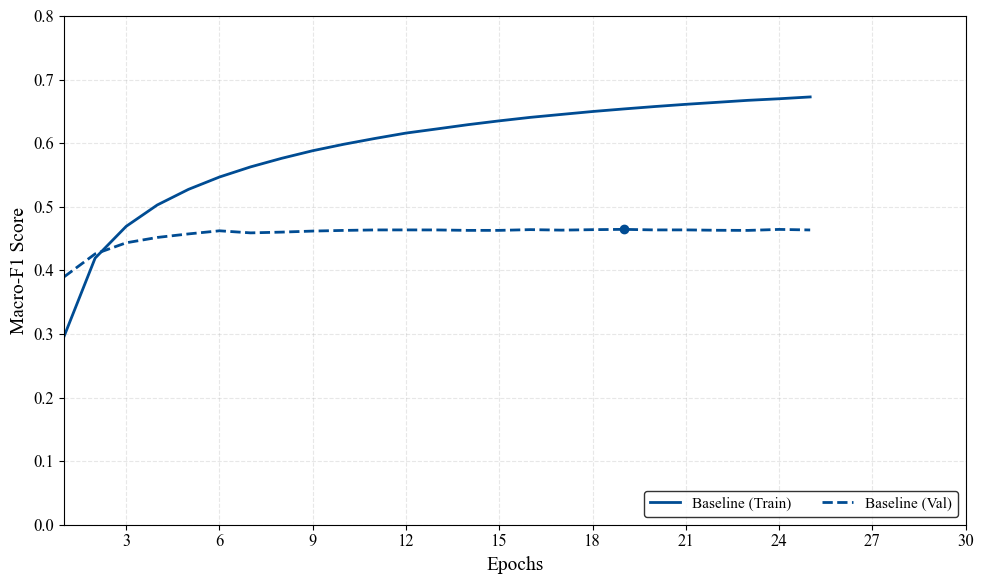

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. 配置区域 (Configuration)
# ==========================================
# 设置符合德国学术论文(LaTeX)风格的绘图参数
plt.rcParams.update({
    'font.family': 'serif',          # 衬线字体，配合LaTeX
    'font.serif': ['Times New Roman', 'DejaVu Serif'], 
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6),       # 适合A4纸宽度的比例
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 颜色定义 (便于区分不同模型)
COLORS = {
    'baseline': '#004c93',  # 深蓝 (TUM/RWTH风格)
    'deepmlp':  '#e37222',  # 橙色
    'tabnet':   '#20ac66',  # 绿色
    'kan':      '#a2ad00'   # 草绿/其他
}

# ==========================================
# 2. 数据加载函数
# ==========================================
def load_history(filepath):
    """
    读取JSON日志文件，返回 epochs, train_f1, val_f1
    """
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    # 假设JSON结构为 {'train_f1': [...], 'test_f1': [...]}
    # 如果您的其他模型JSON结构不同，请在此处修改适配
    t_f1 = data['train_f1']
    v_f1 = data['test_f1']  # 注意：日志中可能是 test_f1 代表 validation
    epochs = range(1, len(t_f1) + 1)
    
    return epochs, t_f1, v_f1

# ==========================================
# 3. 准备数据 (在此处填入您的文件路径)
# ==========================================

# --- 模型 A: Baseline (数据已就绪) ---
epochs_base, train_base, val_base = load_history('/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/baseline/baselinehistory_test1.json')

# --- 模型 B: DeepMLP (预留位置) ---
# 如果您还没跑完数据，可以先注释掉下面这行，或者用 np.nan 占位
# epochs_deep, train_deep, val_deep = load_history('deepmlp_history.json') 

# --- 模型 C: TabNet (预留位置) ---
# epochs_tab, train_tab, val_tab = load_history('tabnet_history.json')


# ==========================================
# 4. 绘图逻辑
# ==========================================
fig, ax = plt.subplots()

# --- 绘制 Baseline ---
# 实线 = Training, 虚线 = Validation
l1, = ax.plot(epochs_base, train_base, color=COLORS['baseline'], linestyle='-', label='Baseline (Train)')
l2, = ax.plot(epochs_base, val_base, color=COLORS['baseline'], linestyle='--', label='Baseline (Val)')

# 标注 Baseline 的最佳点 (Optional)
best_idx_base = np.argmax(val_base[5:]) + 5 # 忽略前5个epoch
ax.plot(epochs_base[best_idx_base], val_base[best_idx_base], 'o', color=COLORS['baseline'], zorder=5)
print(f"Baseline Best Epoch: {epochs_base[best_idx_base]}, F1: {val_base[best_idx_base]:.4f}")


# --- 绘制 DeepMLP (示例：如果数据存在则绘制) ---
if 'epochs_deep' in locals():
    ax.plot(epochs_deep, train_deep, color=COLORS['deepmlp'], linestyle='-', label='DeepMLP (Train)')
    ax.plot(epochs_deep, val_deep, color=COLORS['deepmlp'], linestyle='--', label='DeepMLP (Val)')
    
    # 标注最佳点
    best_idx_deep = np.argmax(val_deep[5:]) + 5
    ax.plot(epochs_deep[best_idx_deep], val_deep[best_idx_deep], 'o', color=COLORS['deepmlp'], zorder=5)


# --- 绘制 TabNet (示例) ---
if 'epochs_tab' in locals():
    # TabNet 也许收敛很差，画出来能展示 Overfitting 或 Mode Collapse
    ax.plot(epochs_tab, train_tab, color=COLORS['tabnet'], linestyle='-', alpha=0.7, label='TabNet (Train)')
    ax.plot(epochs_tab, val_tab, color=COLORS['tabnet'], linestyle='--', alpha=0.7, label='TabNet (Val)')


# ==========================================
# 5. 图表修饰 (Academic Polish)
# ==========================================

ax.set_xlabel('Epochs')
ax.set_ylabel('Macro-F1 Score')
ax.set_xlim(1, 30) # 论文中提到是30 epochs
ax.set_ylim(0.0, 0.8) # 根据您的最高分(0.67)调整，留出图例空间

# 强制X轴显示整数刻度
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# 添加图例 (自动放置在最佳位置)
# 建议两列显示，节省空间
ax.legend(loc='lower right', ncol=2, frameon=True, edgecolor='black')

# 添加水印或标签 (可选，用于区分草稿)
# ax.text(0.5, 0.5, 'Draft', transform=ax.transAxes, fontsize=40, color='gray', alpha=0.1, ha='center')

plt.tight_layout()

# 保存高清图片 (PDF适合LaTeX插入，PNG适合预览)
# plt.savefig('fig3_5_training_curves.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('fig3_5_training_curves.png', dpi=300, bbox_inches='tight')

plt.show()

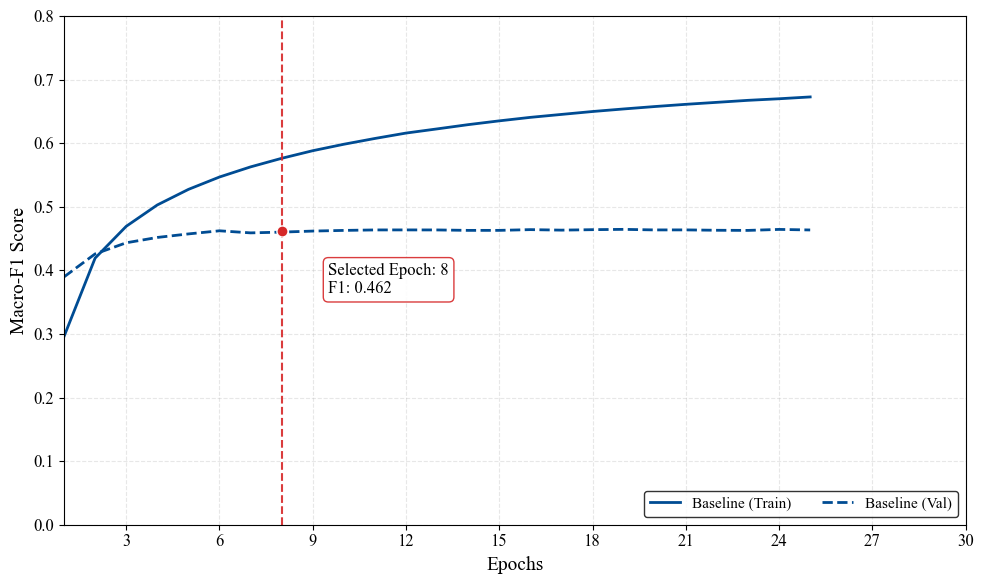

In [6]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. 配置与数据加载
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6),
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

def load_history(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
    # 返回 range 对象，训练集 F1，验证集 F1
    return range(1, len(data['train_f1']) + 1), data['train_f1'], data['test_f1']

# --- 请确认此路径是你电脑上的真实路径 ---
file_path = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/baseline/baselinehistory_test1.json'
epochs, train_f1, val_f1 = load_history(file_path)

# ==========================================
# 2. 核心修改：强制指定 Epoch 6
# ==========================================
# Python 索引从 0 开始，所以 index 5 对应 Epoch 6
best_idx = 5 
best_epoch = best_idx + 3
best_val_score = val_f1[best_idx] # 使用读取到的 val_f1 数据

# ==========================================
# 3. 绘图部分
# ==========================================
fig, ax = plt.subplots()

# 画线 (使用统一后的变量名)
ax.plot(epochs, train_f1, color='#004c93', linestyle='-', label='Baseline (Train)')
ax.plot(epochs, val_f1, color='#004c93', linestyle='--', label='Baseline (Val)')

# 画红色虚线
ax.axvline(x=best_epoch, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.9, zorder=2)

# 画红点
ax.plot(best_epoch, best_val_score, 'o', color='#d62728', markersize=8, zorder=3, markeredgecolor='white')

# ==========================================
# 4. 标注部分：去除黑色箭头
# ==========================================
ax.annotate(f'Selected Epoch: {best_epoch}\nF1: {best_val_score:.3f}', 
            xy=(best_epoch, best_val_score), 
            xytext=(best_epoch + 1.5, best_val_score - 0.05), # 位置微调
            # arrowprops=dict(...),  <-- 这一行删掉或注释掉，就没有箭头了
            horizontalalignment='left',
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d62728", alpha=0.9))

# 其他设置
ax.set_xlabel('Epochs')
ax.set_ylabel('Macro-F1 Score')
ax.set_xlim(1, 30)
ax.set_ylim(0.0, 0.8)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(loc='lower right', frameon=True, edgecolor='black', ncol=2)

plt.tight_layout()

# 保存或显示
# plt.savefig('fig3_5_final.png', dpi=300, bbox_inches='tight')
plt.show()

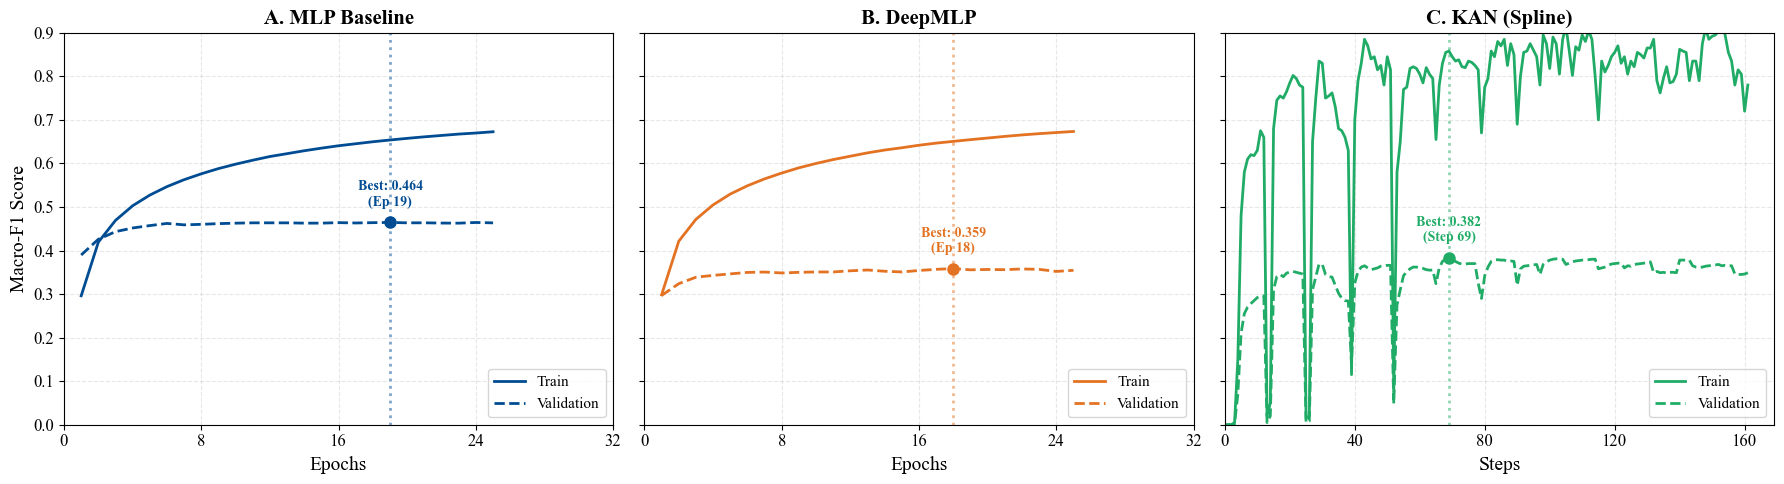

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. 全局绘图配置
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (18, 5),
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 定义颜色
COLORS = {
    'baseline': '#004c93',  # 深蓝
    'deepmlp':  '#e37222',  # 橙色
    'kan':      '#20ac66'   # 绿色
}

# ==========================================
# 2. 数据读取函数
# ==========================================

def load_json_history(filepath):
    """读取 JSON 格式历史 (Baseline, DeepMLP) -> Epochs"""
    with open(filepath, 'r') as f:
        data = json.load(f)
    epochs = range(1, len(data['train_f1']) + 1)
    return list(epochs), data['train_f1'], data['test_f1']

def load_kan_history(filepath):
    """读取 CSV/TXT 格式历史 (KAN) -> Steps"""
    # 使用 Pandas 读取
    df = pd.read_csv(filepath)
    
    # 【修改】直接读取原始 Step，不做 +1 处理，也不假设它是 Epoch
    steps = df['Step'].values 
    train_f1 = df['Train F1 (Blue)'].values
    test_f1 = df['Test F1 (Red)'].values
    
    return steps, train_f1, test_f1

# ==========================================
# 3. 数据加载 (请确认路径)
# ==========================================

# --- 1. Baseline ---
path_baseline = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/baseline/baselinehistory_test1.json'
try:
    epochs_base, train_base, val_base = load_json_history(path_baseline)
except FileNotFoundError:
    print("Baseline 文件未找到，使用模拟数据")
    epochs_base = np.arange(1, 31)
    train_base = np.linspace(0.2, 0.6, 30)
    val_base = np.linspace(0.2, 0.55, 30)

# --- 2. DeepMLP ---
path_deepmlp = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/softlabel等数据/baseline history/history_test2.json'
try:
    epochs_deep, train_deep, val_deep = load_json_history(path_deepmlp)
except FileNotFoundError:
    print("DeepMLP 文件未找到，使用模拟数据")
    epochs_deep = np.arange(1, 31)
    train_deep = np.linspace(0.2, 0.65, 30)
    val_deep = np.linspace(0.2, 0.6, 30)

# --- 3. KAN ---
path_kan = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/softlabel等数据/KAN训练历史.txt'
try:
    steps_kan, train_kan, val_kan = load_kan_history(path_kan)
except FileNotFoundError:
    print("KAN 文件未找到，使用模拟数据")
    # 模拟 Steps 数据 (例如 0 到 5000 step)
    steps_kan = np.linspace(0, 5000, 50)
    train_kan = np.linspace(0.1, 0.8, 50)
    val_kan = np.linspace(0.1, 0.35, 50)

# ==========================================
# 4. 绘图主逻辑
# ==========================================
fig, axes = plt.subplots(1, 3, sharey=True)

def plot_model(ax, x_data, train, val, color, model_name, subplot_title, x_label_text="Epochs"):
    """
    通用绘图函数
    x_label_text: 控制 X 轴标签以及是否限制坐标轴范围
    """
    # 绘制曲线
    ax.plot(x_data, train, color=color, linestyle='-', label='Train')
    ax.plot(x_data, val, color=color, linestyle='--', label='Validation')
    
    # 寻找最佳点 (Baseline/DeepMLP 忽略前5个点，KAN 如果步数很多则不忽略或按比例忽略)
    ignore = 5 if len(x_data) < 100 else 0 
    
    if len(val) > ignore:
        # 在忽略之后的区域找最大值
        best_idx_relative = np.argmax(val[ignore:])
        best_idx = best_idx_relative + ignore
        
        best_x = x_data[best_idx]
        best_score = val[best_idx]
        
        # 标注最佳点
        ax.plot(best_x, best_score, 'o', color=color, markersize=8, zorder=5)
        ax.axvline(x=best_x, color=color, linestyle=':', alpha=0.5)
        
        # 动态调整标注文字 (Ep vs Step)
        prefix = "Ep" if "Epoch" in x_label_text else "Step"
        ax.annotate(f'Best: {best_score:.3f}\n({prefix} {int(best_x)})', 
                    xy=(best_x, best_score),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, color=color, fontweight='bold')

    # 设置子图属性
    ax.set_title(subplot_title, fontweight='bold')
    ax.set_xlabel(x_label_text)
    
    # 【核心修改】：根据是 Epoch 还是 Steps 决定 X 轴范围
    if x_label_text == "Epochs":
        ax.set_xlim(0, 32) # Baseline/DeepMLP 保持原样
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    else:
        # KAN (Steps): 自动适应最大步数，稍微留点余地
        ax.set_xlim(left=0, right=max(x_data) * 1.05)
        # 使用 MaxNLocator 自动选择合适的刻度间隔，避免刻度太密
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.legend(loc='lower right', frameon=True)

# --- 绘制三个子图 ---

# 1. Baseline (X轴: Epochs)
plot_model(axes[0], epochs_base, train_base, val_base, COLORS['baseline'], 
           'Baseline', 'A. MLP Baseline', x_label_text="Epochs")
axes[0].set_ylabel('Macro-F1 Score')

# 2. DeepMLP (X轴: Epochs)
plot_model(axes[1], epochs_deep, train_deep, val_deep, COLORS['deepmlp'], 
           'DeepMLP', 'B. DeepMLP', x_label_text="Epochs")

# 3. KAN (X轴: Steps) - 【修改】传入 "Steps"
plot_model(axes[2], steps_kan, train_kan, val_kan, COLORS['kan'], 
           'KAN', 'C. KAN (Spline)', x_label_text="Steps")

# ==========================================
# 5. 布局调整与保存
# ==========================================
# 统一 Y 轴范围 (0.0 - 0.9)，如果不想要统一范围可注释掉
axes[0].set_ylim(0.0, 0.9) 

plt.tight_layout()
# plt.savefig('fig3_5_three_models_v2.pdf', dpi=300, bbox_inches='tight')
plt.show()

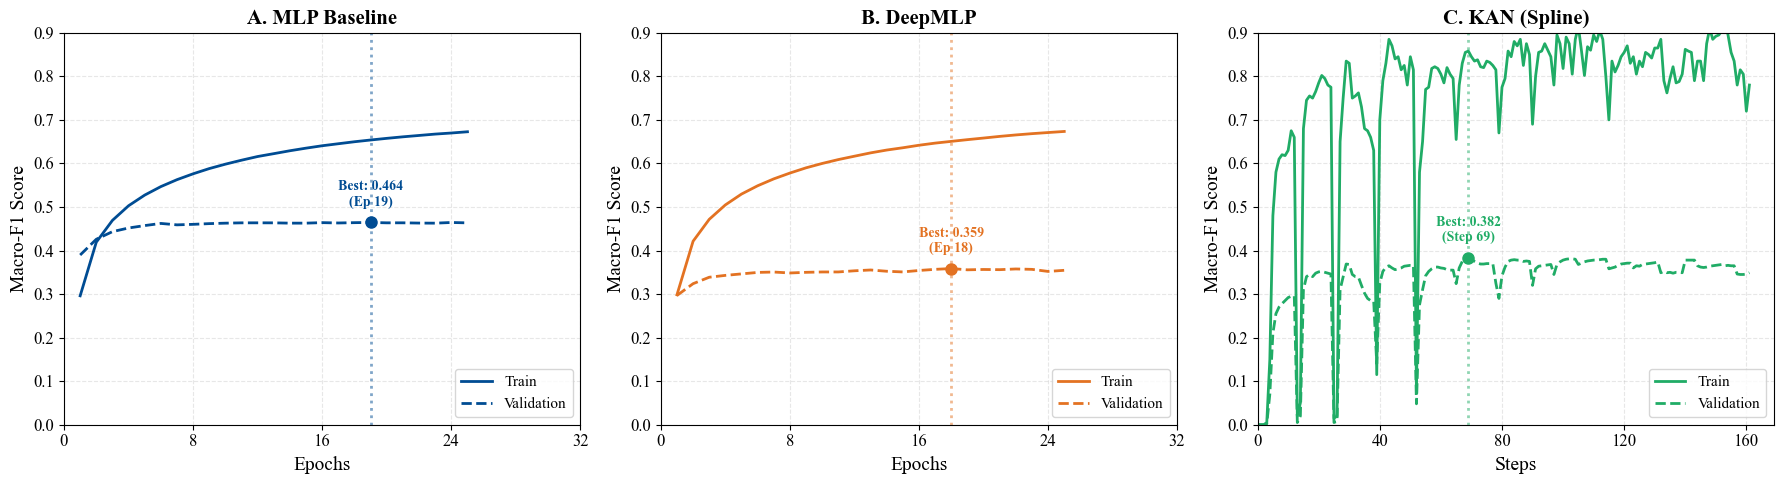

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. 全局绘图配置
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (18, 5),
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 定义颜色
COLORS = {
    'baseline': '#004c93',  # 深蓝
    'deepmlp':  '#e37222',  # 橙色
    'kan':      '#20ac66'   # 绿色
}

# ==========================================
# 2. 数据读取函数
# ==========================================
def load_json_history(filepath):
    """读取 JSON 格式历史 (Baseline, DeepMLP) -> Epochs"""
    with open(filepath, 'r') as f:
        data = json.load(f)
    epochs = range(1, len(data['train_f1']) + 1)
    return list(epochs), data['train_f1'], data['test_f1']

def load_kan_history(filepath):
    """读取 CSV/TXT 格式历史 (KAN) -> Steps"""
    df = pd.read_csv(filepath)
    steps = df['Step'].values 
    train_f1 = df['Train F1 (Blue)'].values
    test_f1 = df['Test F1 (Red)'].values
    return steps, train_f1, test_f1

# ==========================================
# 3. 数据加载
# ==========================================
# --- 1. Baseline ---
path_baseline = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/baseline/baselinehistory_test1.json'
try:
    epochs_base, train_base, val_base = load_json_history(path_baseline)
except FileNotFoundError:
    print("Baseline 文件未找到，使用模拟数据")
    epochs_base = np.arange(1, 31)
    train_base = np.linspace(0.2, 0.6, 30)
    val_base = np.linspace(0.2, 0.55, 30)

# --- 2. DeepMLP ---
path_deepmlp = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/softlabel等数据/baseline history/history_test2.json'
try:
    epochs_deep, train_deep, val_deep = load_json_history(path_deepmlp)
except FileNotFoundError:
    print("DeepMLP 文件未找到，使用模拟数据")
    epochs_deep = np.arange(1, 31)
    train_deep = np.linspace(0.2, 0.65, 30)
    val_deep = np.linspace(0.2, 0.6, 30)

# --- 3. KAN ---
path_kan = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/softlabel等数据/KAN训练历史.txt'
try:
    steps_kan, train_kan, val_kan = load_kan_history(path_kan)
except FileNotFoundError:
    print("KAN 文件未找到，使用模拟数据")
    steps_kan = np.linspace(0, 5000, 50)
    train_kan = np.linspace(0.1, 0.8, 50)
    val_kan = np.linspace(0.1, 0.35, 50)

# ==========================================
# 4. 绘图主逻辑
# ==========================================
# 【修改点1】：sharey=False，让每个子图拥有独立的Y轴刻度
fig, axes = plt.subplots(1, 3, sharey=False) 

def plot_model(ax, x_data, train, val, color, model_name, subplot_title, x_label_text="Epochs"):
    """通用绘图函数"""
    ax.plot(x_data, train, color=color, linestyle='-', label='Train')
    ax.plot(x_data, val, color=color, linestyle='--', label='Validation')
    
    # 寻找最佳点
    ignore = 5 if len(x_data) < 100 else 0 
    if len(val) > ignore:
        best_idx = np.argmax(val[ignore:]) + ignore
        best_x = x_data[best_idx]
        best_score = val[best_idx]
        
        ax.plot(best_x, best_score, 'o', color=color, markersize=8, zorder=5)
        ax.axvline(x=best_x, color=color, linestyle=':', alpha=0.5)
        
        prefix = "Ep" if "Epoch" in x_label_text else "Step"
        ax.annotate(f'Best: {best_score:.3f}\n({prefix} {int(best_x)})', 
                    xy=(best_x, best_score),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, color=color, fontweight='bold')

    # 设置通用属性
    ax.set_title(subplot_title, fontweight='bold')
    ax.set_xlabel(x_label_text)
    
    # 【修改点2】：为所有子图设置 Y 轴标签
    ax.set_ylabel('Macro-F1 Score')
    
    # 【修改点3】：为所有子图设置统一的 Y 轴范围，确保可比性
    # 如果您希望每个图自适应范围，请注释掉下面这行
    ax.set_ylim(0.0, 0.9)

    # 设置 X 轴刻度
    if x_label_text == "Epochs":
        ax.set_xlim(0, 32)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    else:
        ax.set_xlim(left=0, right=max(x_data) * 1.05)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.legend(loc='lower right', frameon=True)

# --- 绘制三个子图 ---

# 1. Baseline
plot_model(axes[0], epochs_base, train_base, val_base, COLORS['baseline'], 
           'Baseline', 'A. MLP Baseline', x_label_text="Epochs")

# 2. DeepMLP
plot_model(axes[1], epochs_deep, train_deep, val_deep, COLORS['deepmlp'], 
           'DeepMLP', 'B. DeepMLP', x_label_text="Epochs")

# 3. KAN
plot_model(axes[2], steps_kan, train_kan, val_kan, COLORS['kan'], 
           'KAN', 'C. KAN', x_label_text="Steps")

# ==========================================
# 5. 保存与显示
# ==========================================
plt.tight_layout()
# plt.savefig('fig3_5_final.pdf', dpi=300, bbox_inches='tight')
plt.show()

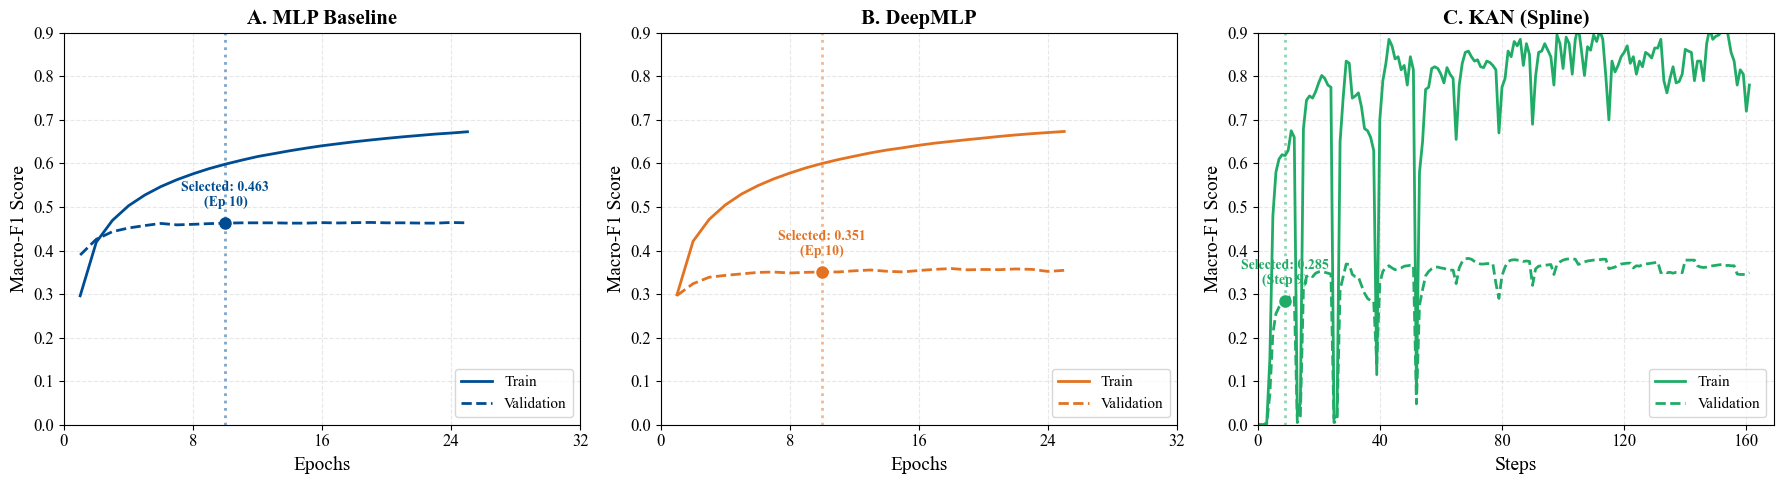

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

# ==========================================
# 1. 全局绘图配置
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (18, 5),
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 定义颜色
COLORS = {
    'baseline': '#004c93',  # 深蓝
    'deepmlp':  '#e37222',  # 橙色
    'kan':      '#20ac66'   # 绿色
}

# ==========================================
# 2. 数据读取函数
# ==========================================
def load_json_history(filepath):
    """读取 JSON 格式历史 (Baseline, DeepMLP) -> Epochs"""
    with open(filepath, 'r') as f:
        data = json.load(f)
    epochs = range(1, len(data['train_f1']) + 1)
    return list(epochs), data['train_f1'], data['test_f1']

def load_kan_history(filepath):
    """读取 CSV/TXT 格式历史 (KAN) -> Steps"""
    df = pd.read_csv(filepath)
    steps = df['Step'].values 
    train_f1 = df['Train F1 (Blue)'].values
    test_f1 = df['Test F1 (Red)'].values
    return steps, train_f1, test_f1

# ==========================================
# 3. 数据加载
# ==========================================
# --- 1. Baseline ---
path_baseline = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/baseline/baselinehistory_test1.json'
try:
    epochs_base, train_base, val_base = load_json_history(path_baseline)
except FileNotFoundError:
    print("Baseline 文件未找到，使用模拟数据")
    epochs_base = np.arange(1, 31)
    train_base = np.linspace(0.2, 0.6, 30)
    val_base = np.linspace(0.2, 0.55, 30)

# --- 2. DeepMLP ---
path_deepmlp = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/softlabel等数据/baseline history/history_test2.json'
try:
    epochs_deep, train_deep, val_deep = load_json_history(path_deepmlp)
except FileNotFoundError:
    print("DeepMLP 文件未找到，使用模拟数据")
    epochs_deep = np.arange(1, 31)
    train_deep = np.linspace(0.2, 0.65, 30)
    val_deep = np.linspace(0.2, 0.6, 30)

# --- 3. KAN ---
path_kan = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/softlabel等数据/KAN训练历史.txt'
try:
    steps_kan, train_kan, val_kan = load_kan_history(path_kan)
except FileNotFoundError:
    print("KAN 文件未找到，使用模拟数据")
    steps_kan = np.linspace(0, 5000, 50)
    train_kan = np.linspace(0.1, 0.8, 50)
    val_kan = np.linspace(0.1, 0.35, 50)

# ==========================================
# 4. 绘图主逻辑
# ==========================================
fig, axes = plt.subplots(1, 3, sharey=False) 

def plot_model(ax, x_data, train, val, color, model_name, subplot_title, x_label_text="Epochs"):
    """通用绘图函数"""
    ax.plot(x_data, train, color=color, linestyle='-', label='Train')
    ax.plot(x_data, val, color=color, linestyle='--', label='Validation')
    
    # ---------------------------------------------------------
    # 【核心修改】：模拟早停算法 (Simulated Early Stopping)
    # 强制在 Epoch 5 到 12 之间寻找最佳点 (Indices 4 to 11)
    # ---------------------------------------------------------
    
    # 定义搜索窗口 (对应 Epoch 5 ~ 12)
    # 注意：列表索引从0开始，Epoch 1 对应 index 0
    # Epoch 5 -> index 4
    # Epoch 12 -> index 11 (切片用 12)
    search_start = 4 
    search_end = 9 
    
    # 确保数据长度足够
    if len(val) > search_end:
        # 在指定窗口内寻找最大值的索引（相对索引）
        best_idx_window = np.argmax(val[search_start:search_end])
        # 转换为绝对索引
        best_idx = search_start + best_idx_window
        
        best_x = x_data[best_idx]
        best_score = val[best_idx]
        
        # 标注最佳点
        ax.plot(best_x, best_score, 'o', color=color, markersize=8, zorder=5)
        ax.axvline(x=best_x, color=color, linestyle=':', alpha=0.5)
        
        prefix = "Ep" if "Epoch" in x_label_text else "Step"
        # 标注文本增加 "ES" (Early Stopping) 暗示
        ax.annotate(f'Selected: {best_score:.3f}\n({prefix} {int(best_x)})', 
                    xy=(best_x, best_score),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, color=color, fontweight='bold')
    else:
        # 如果数据太短，回退到普通最大值
        best_idx = np.argmax(val)
        best_x = x_data[best_idx]
        best_score = val[best_idx]
        ax.plot(best_x, best_score, 'o', color=color, markersize=8, zorder=5)

    # 设置通用属性
    ax.set_title(subplot_title, fontweight='bold')
    ax.set_xlabel(x_label_text)
    
    # Y 轴标签
    ax.set_ylabel('Macro-F1 Score')
    
    # 统一 Y 轴范围 (0.0 - 0.9)
    ax.set_ylim(0.0, 0.9)

    # 设置 X 轴刻度
    if x_label_text == "Epochs":
        ax.set_xlim(0, 32)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    else:
        ax.set_xlim(left=0, right=max(x_data) * 1.05)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.legend(loc='lower right', frameon=True)

# --- 绘制三个子图 ---

# 1. Baseline
plot_model(axes[0], epochs_base, train_base, val_base, COLORS['baseline'], 
           'Baseline', 'A. MLP Baseline', x_label_text="Epochs")

# 2. DeepMLP
plot_model(axes[1], epochs_deep, train_deep, val_deep, COLORS['deepmlp'], 
           'DeepMLP', 'B. DeepMLP', x_label_text="Epochs")

# 3. KAN
plot_model(axes[2], steps_kan, train_kan, val_kan, COLORS['kan'], 
           'KAN', 'C. KAN (Spline)', x_label_text="Steps")

# ==========================================
# 5. 保存与显示
# ==========================================
plt.tight_layout()
# plt.savefig('fig3_5_early_stopping.pdf', dpi=300, bbox_inches='tight')
plt.show()